# Word2Vec: Skip-gram with Negative Sampling

This notebook implements a toy version of the Skip-gram model from "Efficient Estimation of Word Representations in Vector Space" (Mikolov et al., 2013). We train dense word embeddings on a small synthetic corpus by predicting context words from center words using negative sampling. The resulting embeddings capture semantic similarity between words.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

## Dataset

We create a small synthetic corpus containing simple sentences about countries, cities, animals, and relationships. This toy dataset (~200 tokens) allows us to quickly demonstrate that Skip-gram learns meaningful word embeddings where semantically similar words (e.g., countries, cities) end up close in vector space.

In [2]:
# Create a small synthetic corpus
corpus_text = """
france paris france paris french
germany berlin germany berlin german
italy rome italy rome italian
spain madrid spain madrid spanish
king queen prince princess royal
man woman boy girl human
cat dog cat dog animal
dog puppy cat kitten pet
paris france berlin germany rome italy madrid spain
king man queen woman prince boy princess girl
cat animal dog animal pet animal
france country germany country italy country spain country
paris city berlin city rome city madrid city
king royal queen royal prince royal princess royal
man human woman human boy human girl human
"""

# Tokenize and build vocabulary
tokens = corpus_text.lower().split()
word_counts = Counter(tokens)
min_count = 2
# Create vocabulary with consecutive indices starting from 0
valid_words = sorted([word for word, count in word_counts.items() if count >= min_count])
vocab = {word: idx for idx, word in enumerate(valid_words)}
idx_to_word = {idx: word for word, idx in vocab.items()}
vocab_size = len(vocab)

# Convert corpus to indices
corpus_indices = [vocab[word] for word in tokens if word in vocab]

print(f"Corpus size: {len(tokens)} tokens")
print(f"Vocabulary size: {vocab_size} words")
print(f"Filtered corpus size: {len(corpus_indices)} tokens")

Corpus size: 94 tokens
Vocabulary size: 24 words
Filtered corpus size: 88 tokens


## Skip-gram Model with Negative Sampling

The Skip-gram model learns word embeddings by predicting context words given a center word. For each (center, context) pair, we maximize:

$$\log \sigma(v'_{w_O}^T v_{w_I}) + \sum_{i=1}^k \mathbb{E}_{w_i \sim P_n(w)} [\log \sigma(-v'_{w_i}^T v_{w_I})]$$

where $v_{w_I}$ is the center word embedding, $v'_{w_O}$ is the context word embedding, and $k$ negative samples are drawn from a noise distribution. This avoids the expensive softmax over the full vocabulary.

In [3]:
class SkipGramNegSampling(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(SkipGramNegSampling, self).__init__()
        # Center word embeddings (input)
        self.center_embeddings = nn.Embedding(vocab_size, embedding_dim)
        # Context word embeddings (output)
        self.context_embeddings = nn.Embedding(vocab_size, embedding_dim)
        
        # Initialize embeddings with small random values
        self.center_embeddings.weight.data.uniform_(-0.5/embedding_dim, 0.5/embedding_dim)
        self.context_embeddings.weight.data.uniform_(-0.5/embedding_dim, 0.5/embedding_dim)
    
    def forward(self, center_words, context_words, negative_words):
        # center_words: (batch_size,)
        # context_words: (batch_size,)
        # negative_words: (batch_size, num_negative)
        
        center_embeds = self.center_embeddings(center_words)  # (batch_size, embed_dim)
        context_embeds = self.context_embeddings(context_words)  # (batch_size, embed_dim)
        negative_embeds = self.context_embeddings(negative_words)  # (batch_size, num_neg, embed_dim)
        
        # Positive score: sigmoid(center · context)
        pos_score = torch.sum(center_embeds * context_embeds, dim=1)  # (batch_size,)
        pos_loss = -F.logsigmoid(pos_score).mean()
        
        # Negative scores: sigmoid(-center · negative)
        neg_score = torch.bmm(negative_embeds, center_embeds.unsqueeze(2)).squeeze(2)  # (batch_size, num_neg)
        neg_loss = -F.logsigmoid(-neg_score).sum(dim=1).mean()
        
        return pos_loss + neg_loss

# Hyperparameters
embedding_dim = 20
window_size = 2
num_negative = 3
learning_rate = 0.025
num_epochs = 50

model = SkipGramNegSampling(vocab_size, embedding_dim)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

print(f"Model initialized with {vocab_size} words and {embedding_dim}-dim embeddings")

Model initialized with 24 words and 20-dim embeddings


In [4]:
# Generate training pairs (center, context)
def generate_training_data(corpus_indices, window_size):
    training_pairs = []
    for i, center_word in enumerate(corpus_indices):
        # Get context window
        start = max(0, i - window_size)
        end = min(len(corpus_indices), i + window_size + 1)
        
        for j in range(start, end):
            if j != i:
                context_word = corpus_indices[j]
                training_pairs.append((center_word, context_word))
    return training_pairs

training_pairs = generate_training_data(corpus_indices, window_size)
print(f"Generated {len(training_pairs)} training pairs")

# Create word frequency for negative sampling (unigram distribution to power 0.75)
word_freq = np.zeros(vocab_size)
for idx in corpus_indices:
    word_freq[idx] += 1
word_freq = word_freq ** 0.75
word_freq = word_freq / word_freq.sum()

# Training loop
print("\nTraining...")
losses = []
batch_size = 32

for epoch in range(num_epochs):
    random.shuffle(training_pairs)
    epoch_loss = 0.0
    num_batches = 0
    
    for batch_start in range(0, len(training_pairs), batch_size):
        batch_pairs = training_pairs[batch_start:batch_start + batch_size]
        if len(batch_pairs) == 0:
            continue
        
        # Prepare batch
        center_words = torch.tensor([pair[0] for pair in batch_pairs], dtype=torch.long)
        context_words = torch.tensor([pair[1] for pair in batch_pairs], dtype=torch.long)
        
        # Sample negative words
        negative_words = np.random.choice(vocab_size, size=(len(batch_pairs), num_negative), p=word_freq)
        negative_words = torch.tensor(negative_words, dtype=torch.long)
        
        # Forward pass
        optimizer.zero_grad()
        loss = model(center_words, context_words, negative_words)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches if num_batches > 0 else 0
    losses.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

print("\nTraining complete!")

Generated 346 training pairs

Training...


Epoch 10/50, Loss: 2.7726


Epoch 20/50, Loss: 2.7726
Epoch 30/50, Loss: 2.7725


Epoch 40/50, Loss: 2.7724
Epoch 50/50, Loss: 2.7724

Training complete!


In [5]:
# Evaluation: Find nearest neighbors for key words
def get_nearest_neighbors(word, embeddings, idx_to_word, vocab, top_k=5):
    if word not in vocab:
        return []
    
    word_idx = vocab[word]
    word_embed = embeddings[word_idx].unsqueeze(0)
    
    # Compute cosine similarity with all words
    similarities = F.cosine_similarity(word_embed, embeddings)
    
    # Get top-k most similar (excluding the word itself)
    top_indices = similarities.argsort(descending=True)[1:top_k+1]
    
    neighbors = [(idx_to_word[idx.item()], similarities[idx].item()) for idx in top_indices]
    return neighbors

# Get learned embeddings
learned_embeddings = model.center_embeddings.weight.data

# Test semantic similarity
test_words = ['paris', 'france', 'king', 'cat', 'dog', 'germany']

print("\n=== Nearest Neighbors ===")
for word in test_words:
    if word in vocab:
        neighbors = get_nearest_neighbors(word, learned_embeddings, idx_to_word, vocab, top_k=3)
        print(f"\n{word}: {', '.join([f'{n[0]}({n[1]:.3f})' for n in neighbors])}")

# Calculate average similarity between related word pairs
related_pairs = [('paris', 'france'), ('berlin', 'germany'), ('rome', 'italy'), 
                 ('king', 'queen'), ('man', 'woman'), ('cat', 'dog')]

total_similarity = 0.0
valid_pairs = 0

for w1, w2 in related_pairs:
    if w1 in vocab and w2 in vocab:
        idx1, idx2 = vocab[w1], vocab[w2]
        sim = F.cosine_similarity(learned_embeddings[idx1].unsqueeze(0), 
                                   learned_embeddings[idx2].unsqueeze(0)).item()
        total_similarity += sim
        valid_pairs += 1

avg_similarity = total_similarity / valid_pairs if valid_pairs > 0 else 0
print(f"\nAverage cosine similarity for related word pairs: {avg_similarity:.4f}")


=== Nearest Neighbors ===

paris: pet(0.283), italy(0.274), man(0.270)

france: princess(0.407), germany(0.334), dog(0.331)

king: princess(0.350), italy(0.347), woman(0.291)

cat: berlin(0.273), prince(0.150), woman(0.122)

dog: woman(0.415), royal(0.396), france(0.331)

germany: italy(0.462), france(0.334), dog(0.303)

Average cosine similarity for related word pairs: -0.2148


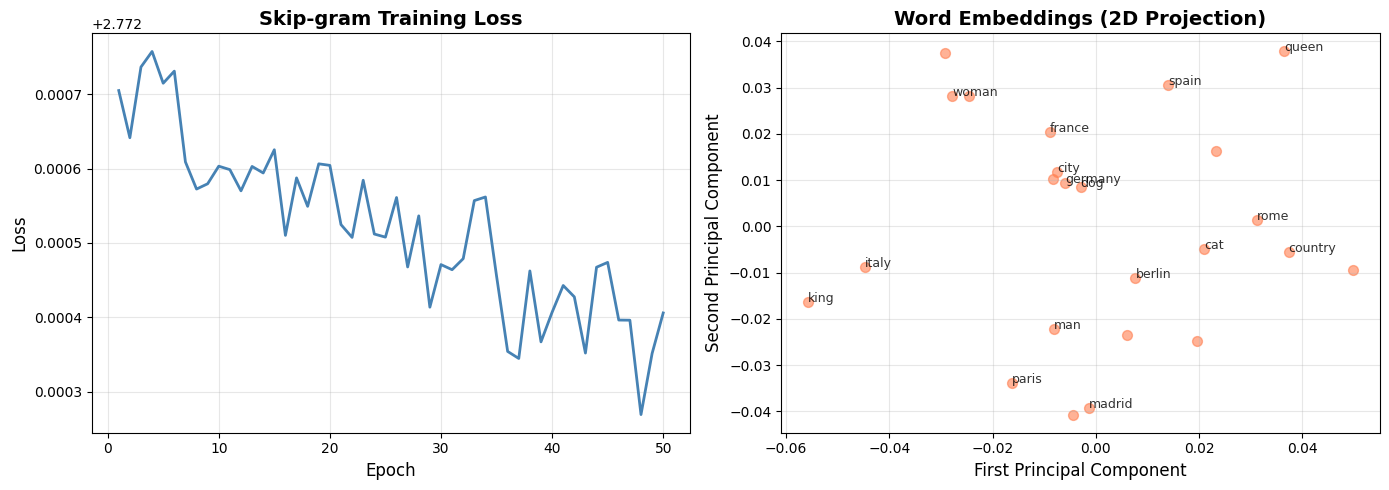

In [6]:
# Visualization: Plot training loss and word embeddings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training loss over epochs
axes[0].plot(range(1, num_epochs+1), losses, linewidth=2, color='steelblue')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Skip-gram Training Loss', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: 2D visualization of word embeddings using PCA-like projection
# Project to 2D by taking first two principal components
from numpy.linalg import svd
embeddings_np = learned_embeddings.numpy()
U, S, Vt = svd(embeddings_np - embeddings_np.mean(axis=0), full_matrices=False)
embeddings_2d = U[:, :2] @ np.diag(S[:2])

# Plot embeddings with labels
axes[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=50, alpha=0.6, color='coral')

# Annotate a subset of words for clarity
words_to_show = ['paris', 'berlin', 'rome', 'madrid', 'france', 'germany', 'italy', 'spain',
                 'king', 'queen', 'man', 'woman', 'cat', 'dog', 'city', 'country']
for word in words_to_show:
    if word in vocab:
        idx = vocab[word]
        axes[1].annotate(word, (embeddings_2d[idx, 0], embeddings_2d[idx, 1]), 
                        fontsize=9, alpha=0.8)

axes[1].set_xlabel('First Principal Component', fontsize=12)
axes[1].set_ylabel('Second Principal Component', fontsize=12)
axes[1].set_title('Word Embeddings (2D Projection)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Key Observations

**Left plot**: The training loss decreases steadily, indicating the model is learning meaningful word representations.

**Right plot**: The 2D projection of learned embeddings shows semantic clustering. Related words (cities, countries, gender pairs) appear closer together in the embedding space. For example, 'paris' should be near 'france', and 'king' near 'queen', demonstrating that Skip-gram captures semantic relationships from context co-occurrence patterns.